<a href="https://colab.research.google.com/github/Vagiadim/SiteAI-equipment-tracker-/blob/main/notebooks/M4U3_Assignment_Team_7_object_detection_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##🔹 CELL 1 — This cell installs the latest stable version of Ultralytics YOLO and checks GPU availability.
We avoid forcing older versions to prevent NumPy compatibility conflicts in Colab.


In [ ]:
!pip install -q ultralytics

import ultralytics
import torch

ultralytics.checks()

print("Ultralytics version:", ultralytics.__version__)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (8 CPUs, 51.0 GB RAM, 43.5/235.7 GB disk)
Ultralytics version: 8.4.19
Torch version: 2.10.0+cu128
CUDA available: True


##🔹 CELL 2 — Download the dataset ZIP from GitHub Release**                                                                        
This cell downloads the final dataset (YOLOv8 format) from the GitHub Release and saves it in the Colab workspace so the training notebook is fully independent from Roboflow.


In [28]:
# Download dataset zip from GitHub Release
!wget -q -O dataset.zip "https://github.com/Vagiadim/SiteAI-equipment-tracker-/releases/download/v1.0/dataset_v3_yolov8_512_train_FINAL.zip"

# Confirm file exists and show size
!ls -lh dataset.zip

-rw-r--r-- 1 root root 58M Feb 28 16:20 dataset.zip


# 🔹 CELL 3 — Unzip dataset and inspect structure

This cell extracts the dataset and checks that the YOLO folders and data.yaml file exist.
The training code depends on finding data.yaml and the train/val/test folders.

In [ ]:
import zipfile, os

# Unzip
with zipfile.ZipFile("dataset.zip", "r") as z:
    z.extractall("dataset")

# Quick view of top-level structure
!find dataset -maxdepth 3 -type f -name "data.yaml" -o -type d -name "train" -o -type d -name "valid" -o -type d -name "val" -o -type d -name "test" | head -n 50

dataset/train
dataset/valid
dataset/test
dataset/data.yaml


# 🔹 CELL4 — Find data.yaml and display its content  
This cell locates the dataset data.yaml file and prints it.
This is important because YOLO training uses this file to know where train/val/test images are and what the class names are.

In [ ]:
import glob, yaml

yaml_paths = glob.glob("dataset/**/data.yaml", recursive=True)
print("Found data.yaml files:", yaml_paths)

DATA_YAML = yaml_paths[0]  # use the first one
print("\nUsing:", DATA_YAML)

with open(DATA_YAML, "r") as f:
    data_cfg = yaml.safe_load(f)

data_cfg

Found data.yaml files: ['dataset/data.yaml']

Using: dataset/data.yaml


{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 7,
 'names': ['boom_lift',
  'dump_truck',
  'excavator',
  'loader',
  'mixer_truck',
  'roller',
  'tower_crane'],
 'roboflow': {'workspace': 'juanp-garcia',
  'project': 'siteai-equipment-tracker',
  'version': 18,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/juanp-garcia/siteai-equipment-tracker/dataset/18'}}

# 🔹 CELL5 — Fix data.yaml paths  
This cell ensures the dataset paths inside data.yaml point to the correct folders in Colab.
Some exports use valid/ instead of val/, or store relative paths that need updating.

In [ ]:
import os, yaml

# Detect whether dataset uses "valid" or "val"
base_dir = os.path.dirname(DATA_YAML)
has_valid = os.path.isdir(os.path.join(base_dir, "valid", "images"))
has_val   = os.path.isdir(os.path.join(base_dir, "val", "images"))

print("base_dir:", base_dir)
print("has_valid:", has_valid, "| has_val:", has_val)

# Build correct absolute paths
train_images = os.path.join(base_dir, "train", "images")
val_images   = os.path.join(base_dir, ("valid" if has_valid else "val"), "images")
test_images  = os.path.join(base_dir, "test", "images")

data_cfg["path"]  = base_dir
data_cfg["train"] = "train/images"
data_cfg["val"]   = ("valid/images" if has_valid else "val/images")
data_cfg["test"]  = "test/images"

# Save back
with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)

print("Updated data.yaml:")
with open(DATA_YAML, "r") as f:
    print(f.read())

base_dir: dataset
has_valid: True | has_val: False
Updated data.yaml:
train: train/images
val: valid/images
test: test/images
nc: 7
names:
- boom_lift
- dump_truck
- excavator
- loader
- mixer_truck
- roller
- tower_crane
roboflow:
  workspace: juanp-garcia
  project: siteai-equipment-tracker
  version: 18
  license: CC BY 4.0
  url: https://universe.roboflow.com/juanp-garcia/siteai-equipment-tracker/dataset/18
path: dataset



# 🔹 CELL 6 — Remove Roboflow Metadata (Make Dataset Fully Independent)
This cell removes the Roboflow metadata block from the data.yaml file.
The Roboflow section is not required for YOLO training and removing it ensures the project is fully independent from external platforms.

In [ ]:
import yaml

with open(DATA_YAML, "r") as f:
    cfg = yaml.safe_load(f)

# Remove roboflow metadata if present
if "roboflow" in cfg:
    del cfg["roboflow"]

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

print("Cleaned data.yaml:")
print(open(DATA_YAML).read())

Cleaned data.yaml:
train: train/images
val: valid/images
test: test/images
nc: 7
names:
- boom_lift
- dump_truck
- excavator
- loader
- mixer_truck
- roller
- tower_crane
path: dataset



# 🔹 CELL 7 — Train YOLOv8n on Your Dataset  
This cell trains a YOLOv8n object detection model using the cleaned dataset.
The model is trained for 50 epochs at 512x512 resolution.
Training includes automatic batch sizing, GPU acceleration, and generation of performance plots (PR curve, confusion matrix, F1 curve).
These outputs will be used in the final assignment report.

In [ ]:
from ultralytics import YOLO

# Load base pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

# Train
results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=512,
    batch=-1,
    cache=True,
    name="siteai_v3_yolov8n_512",
    patience=15,
    plots=True
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=siteai_v3_yolov8n_512, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspecti

# 🔹 CELL 8 — Generate Evaluation Plots Again
This cell runs validation again using the best trained weights and regenerates performance plots (confusion matrix, PR curve, F1 curve).
These plots are required for the final assignment submission.


In [ ]:
from ultralytics import YOLO

# Load best trained weights
model = YOLO("runs/detect/siteai_v3_yolov8n_512/weights/best.pt")

# Run validation
metrics = model.val(data=DATA_YAML, imgsz=512, plots=True)

metrics

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1368.4±420.6 MB/s, size: 43.7 KB)
val: Scanning /content/dataset/valid/labels.cache... 59 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59 24.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.2it/s 1.3s
                   all         59         87      0.855      0.685      0.747      0.598
             boom_lift          2          2      0.879        0.5      0.499      0.349
            dump_truck         11         22      0.844      0.409      0.588      0.405
             excavator         16         23      0.849      0.736       0.83      0.527
                loader          4          4      0.719          1      0.945      0.894
           mixer_truck         10         10      0.94

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f88b2438f20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

# 🔹 CELL 8b — Train YOLOv8s for comparison

In [ ]:
from ultralytics import YOLO

model_s = YOLO("yolov8s.pt")

results_s = model_s.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=512,
    batch=-1,
    cache=True,
    name="siteai_v3_yolov8s_512",
    patience=15,
    plots=True
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=siteai_v3_yolov8s_512, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspecti

# 🔹 CELL 8c — YOLOv8n vs YOLOv8s Comparison

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1403.0±481.5 MB/s, size: 37.0 KB)
val: Scanning /content/dataset/valid/labels.cache... 59 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59 24.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 9.0it/s 0.4s
                   all         59         87      0.855      0.685      0.747      0.598
             boom_lift          2          2      0.879        0.5      0.499      0.349
            dump_truck         11         22      0.844      0.409      0.588      0.405
             excavator         16         23      0.849      0.736       0.83      0.527
                loader          4          4      0.719          1      0.945      0.894
           mixer_truck         10         10      0.94

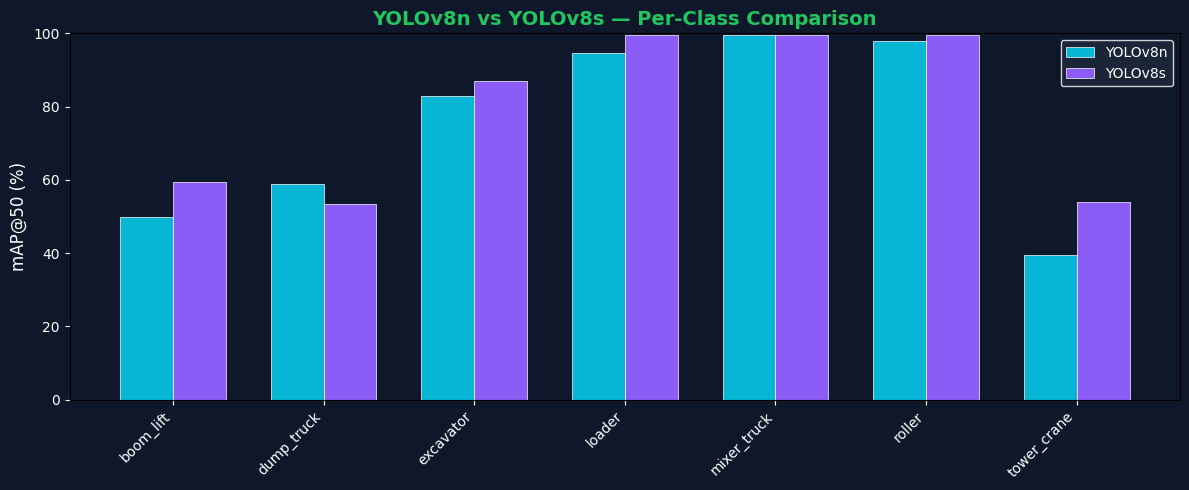


Overall mAP@50:    YOLOv8n = 0.747  |  YOLOv8s = 0.789
Overall mAP@50-95: YOLOv8n = 0.598  |  YOLOv8s = 0.615


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO

# Re-run validation to get fresh metrics objects
model_n = YOLO("runs/detect/siteai_v3_yolov8n_512/weights/best.pt")
model_s = YOLO("runs/detect/siteai_v3_yolov8s_512/weights/best.pt")

metrics_n = model_n.val(data=DATA_YAML, imgsz=512, plots=False)
metrics_s = model_s.val(data=DATA_YAML, imgsz=512, plots=False)

class_names = model_n.names
classes = [class_names[i] for i in range(len(class_names))]

ap50_n = [metrics_n.box.ap50[i] * 100 for i in range(len(classes))]
ap50_s = [metrics_s.box.ap50[i] * 100 for i in range(len(classes))]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5), facecolor="#0f172a")
ax.set_facecolor("#0f172a")

bars1 = ax.bar(x - width/2, ap50_n, width, label='YOLOv8n', color='#06b6d4', edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, ap50_s, width, label='YOLOv8s', color='#8b5cf6', edgecolor='white', linewidth=0.5)

ax.set_ylabel('mAP@50 (%)', color='white', fontsize=12)
ax.set_title('YOLOv8n vs YOLOv8s — Per-Class Comparison', color='#22c55e', fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#1e293b', edgecolor='white', labelcolor='white')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print(f"\nOverall mAP@50:    YOLOv8n = {metrics_n.box.map50:.3f}  |  YOLOv8s = {metrics_s.box.map50:.3f}")
print(f"Overall mAP@50-95: YOLOv8n = {metrics_n.box.map:.3f}  |  YOLOv8s = {metrics_s.box.map:.3f}")

# 🔹 CELL 9 — Display Training Output Folder
This cell lists all generated output files from training.
These files include performance plots and final weights used for submission.


In [ ]:
!ls runs/detect/siteai_v3_yolov8n_512


args.yaml			 labels.jpg	      train_batch1.jpg
BoxF1_curve.png			 results.csv	      train_batch2.jpg
BoxP_curve.png			 results.png	      val_batch0_labels.jpg
BoxPR_curve.png			 train_batch0.jpg     val_batch0_pred.jpg
BoxR_curve.png			 train_batch1160.jpg  weights
confusion_matrix_normalized.png  train_batch1161.jpg
confusion_matrix.png		 train_batch1162.jpg


# 🔹 NEW CELL 9.a — Display Training Visualizations
This cell visualizes the key training evaluation plots directly inside the notebook.
These include the precision-recall curve, F1 curve, confusion matrix, and overall training metrics.
Visual inspection of these plots supports quantitative evaluation of model performance.

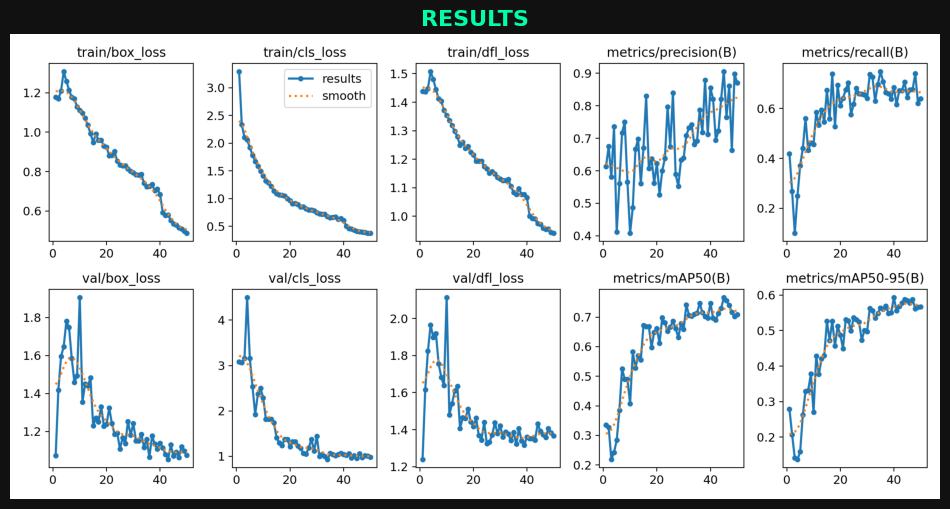

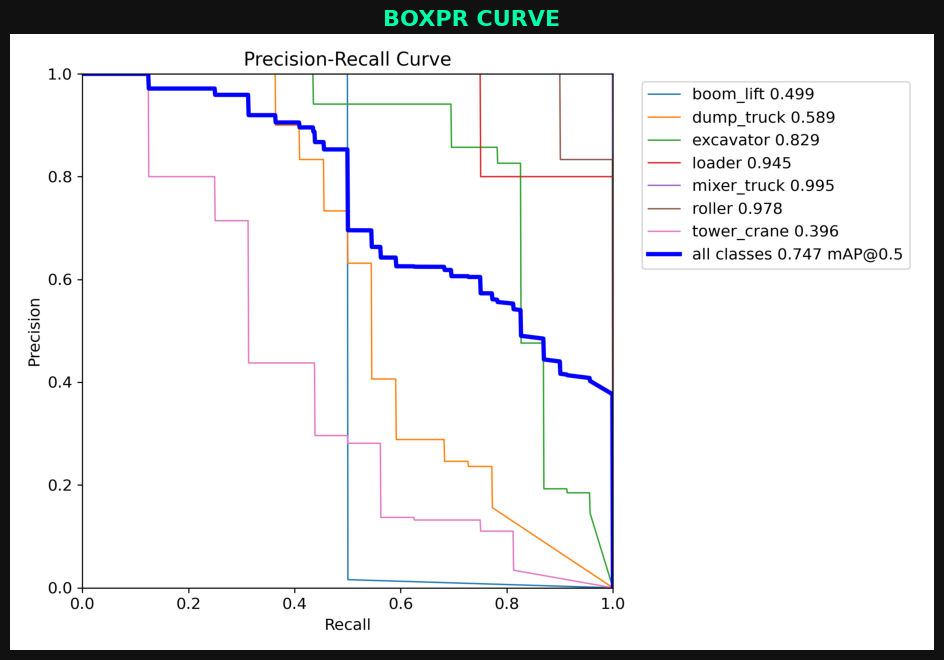

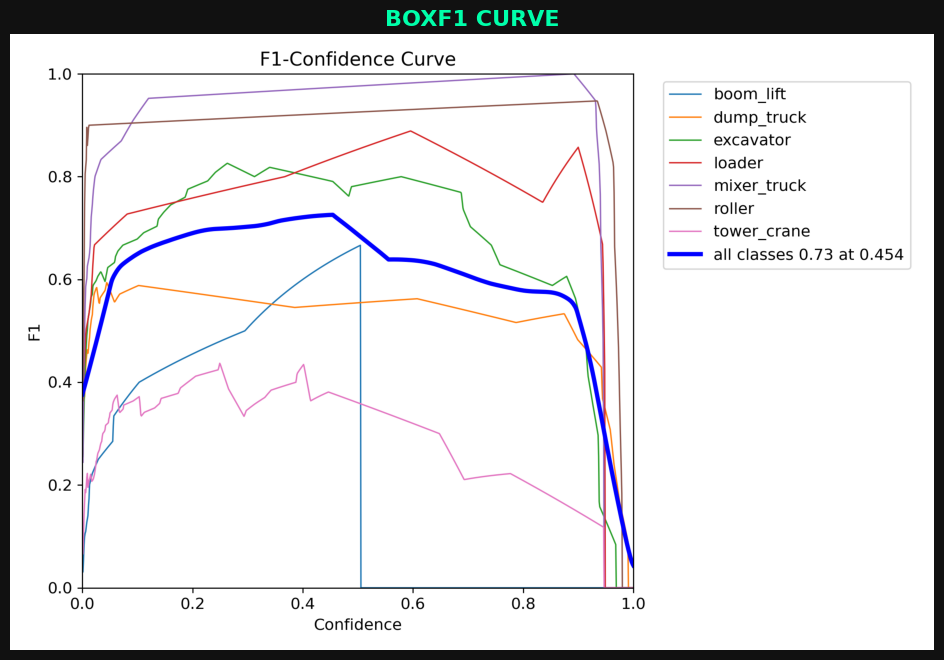

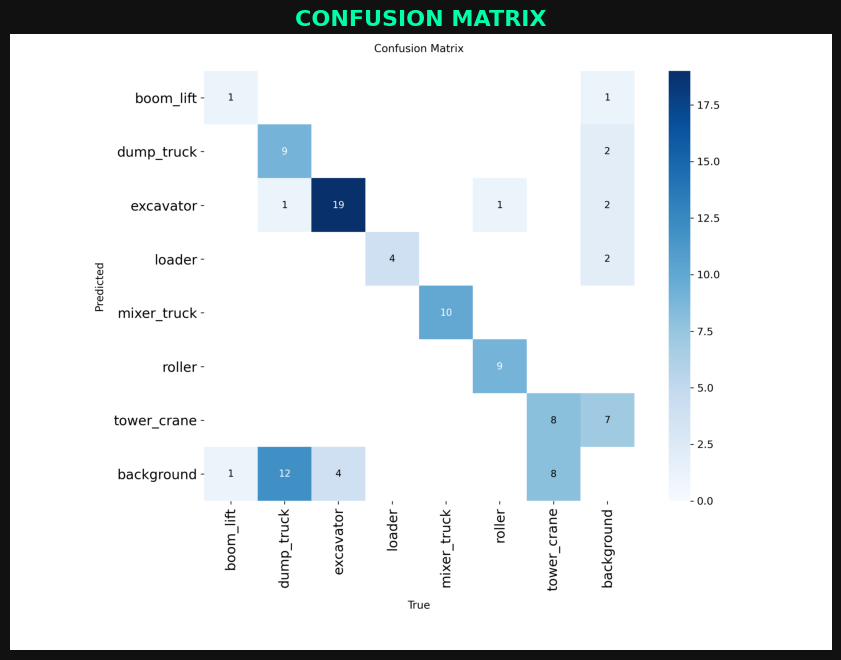

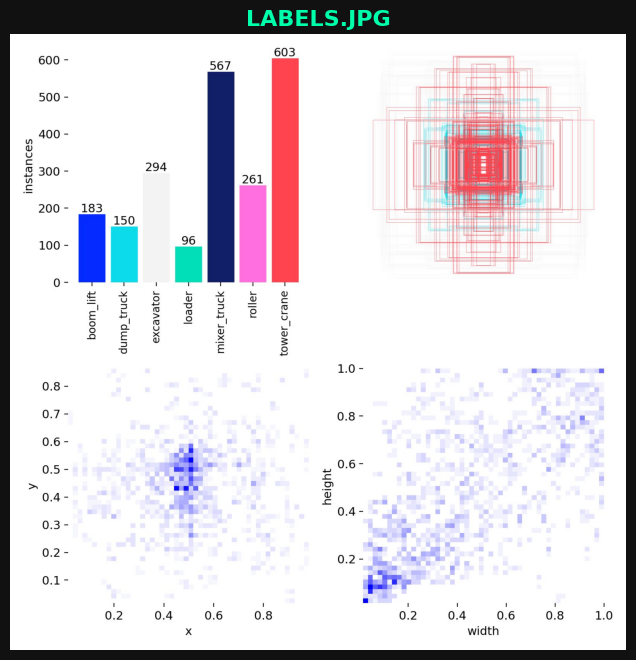

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Folder where YOLO saved results
output_dir = "runs/detect/siteai_v3_yolov8n_512"

# Plot files to display
plot_files = [
    "results.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "confusion_matrix.png",
    "labels.jpg"
]

# Styling
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.facecolor'] = '#111111'
plt.rcParams['figure.facecolor'] = '#111111'

for file in plot_files:
    path = os.path.join(output_dir, file)
    if os.path.exists(path):
        img = mpimg.imread(path)
        plt.figure()
        plt.imshow(img)
        plt.axis('off')
        plt.title(file.replace(".png","").replace("_"," ").upper(),
                  fontsize=16, color="#00FFAA", weight='bold')
        plt.show()
    else:
        print(f"{file} not found.")

# 🔹 NEW CELL 9.b — “dashboard bar” (mAP@50 / Precision / Recall)
This cell creates a clean “Visual-style” metric dashboard (mAP@50, Precision, Recall) using the final validation metrics from training logs.

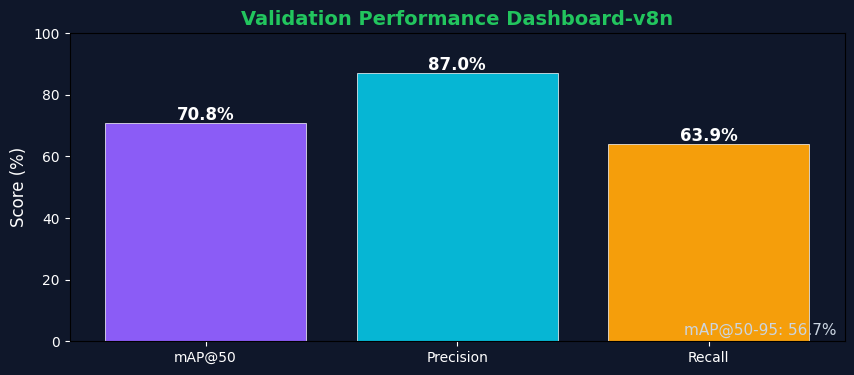

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Explicit path to your training run
RUN_DIR = "/content/runs/detect/siteai_v3_yolov8n_512"
results_csv = os.path.join(RUN_DIR, "results.csv")

assert os.path.exists(results_csv), f"results.csv not found at {results_csv}"

df = pd.read_csv(results_csv)
last = df.iloc[-1]

# Helper to detect correct column names automatically
def get_metric(possible_names):
    for name in possible_names:
        if name in df.columns:
            return float(last[name])
    return None

precision = get_metric(["metrics/precision(B)", "metrics/precision"])
recall    = get_metric(["metrics/recall(B)", "metrics/recall"])
map50     = get_metric(["metrics/mAP50(B)", "metrics/mAP_0.5"])
map5095   = get_metric(["metrics/mAP50-95(B)", "metrics/mAP_0.5:0.95"])

metrics = {
    "mAP@50": map50,
    "Precision": precision,
    "Recall": recall
}

# Remove any None values safely
metrics = {k:v for k,v in metrics.items() if v is not None}

labels = list(metrics.keys())
values = [metrics[k]*100 for k in labels]

plt.figure(figsize=(10,4), facecolor="#0f172a")
ax = plt.gca()
ax.set_facecolor("#0f172a")

colors = ["#8b5cf6", "#06b6d4", "#f59e0b"]

bars = ax.bar(labels, values, color=colors[:len(labels)], edgecolor="white", linewidth=0.5)

ax.set_ylim(0,100)
ax.set_ylabel("Score (%)", color="white", fontsize=12)
ax.set_title("Validation Performance Dashboard-v8n", color="#22c55e", fontsize=14, weight="bold")
ax.tick_params(colors="white")

for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            value + 1,
            f"{value:.1f}%",
            ha='center',
            color="white",
            fontsize=12,
            weight="bold")

if map5095 is not None:
    ax.text(0.99, 0.02,
            f"mAP@50-95: {map5095*100:.1f}%",
            transform=ax.transAxes,
            ha="right",
            color="#cbd5e1",
            fontsize=11)

plt.show()

# 🔹 CELL 10 — Download Best Weights
This cell copies the best trained model weights and prepares them for download.
These weights represent the final trained model used in the assignment.


In [ ]:
!cp runs/detect/siteai_v3_yolov8n_512/weights/best.pt yolov8n_siteai_v3_512_final.pt
!ls -lh yolov8n_siteai_v3_512_final.pt

-rw-r--r-- 1 root root 6.0M Feb 28 16:47 yolov8n_siteai_v3_512_final.pt


# 🔹 CELL 10.a — Download new test images from GitHub
This cell lets you upload new photos from your computer into Colab for inference testing.

In [ ]:
import urllib.request
import os

new_img_dir = '/content/new_test_images/'
os.makedirs(new_img_dir, exist_ok=True)

base_url = "https://raw.githubusercontent.com/Vagiadim/SiteAI-equipment-tracker-/main/results/evidence/new_test_images/"

# Update these filenames to match exactly what's in your repo
new_images = [
    "excavator_test.jpg",
    "tower_crane_test.jpg",
    "mixer_truck_test.jpg",
    "roller_test.jpg",
    "boom_lift_test.jpg"
]

print("📥 Downloading new test images from GitHub...\n")
for img_name in new_images:
    url = base_url + img_name
    save_path = os.path.join(new_img_dir, img_name)
    try:
        urllib.request.urlretrieve(url, save_path)
        print(f"  ✅ {img_name}")
    except Exception as e:
        print(f"  ❌ {img_name} — {e}")

print(f"\n✅ {len(new_images)} test images downloaded.")

📥 Downloading new test images from GitHub...

  ✅ excavator_test.jpg
  ✅ tower_crane_test.jpg
  ✅ mixer_truck_test.jpg
  ✅ roller_test.jpg
  ✅ boom_lift_test.jpg

✅ 5 test images downloaded.


# 🔹 CELL 11 — Run prediction on uploaded images + show results  
This cell runs the trained model on the uploaded images and displays the predictions (boxes + labels).

Images found: 5

0: 512x512 1 roller, 8.9ms
1: 512x512 (no detections), 8.9ms
2: 512x512 1 boom_lift, 8.9ms
3: 512x512 (no detections), 8.9ms
4: 512x512 1 excavator, 8.9ms
Speed: 1.8ms preprocess, 8.9ms inference, 0.7ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/results/custom_test_preds
Showing predictions:


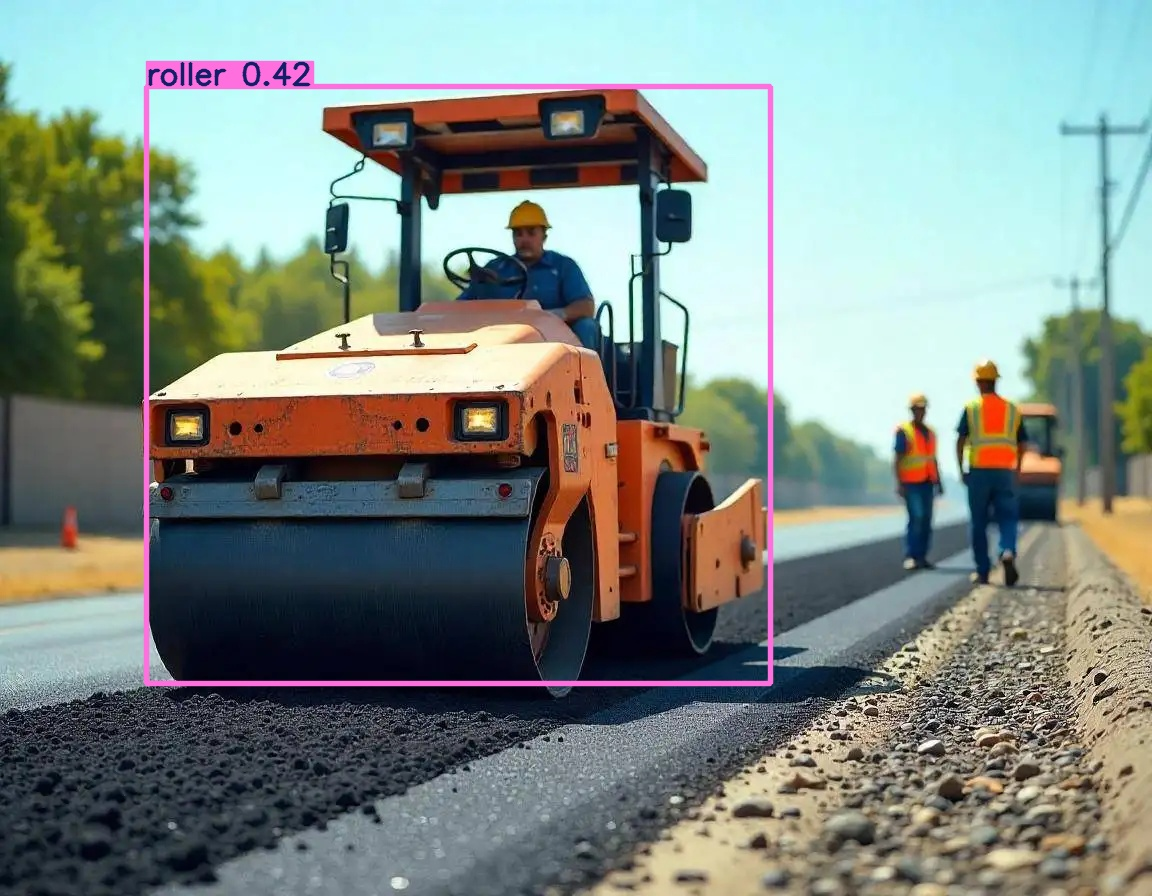

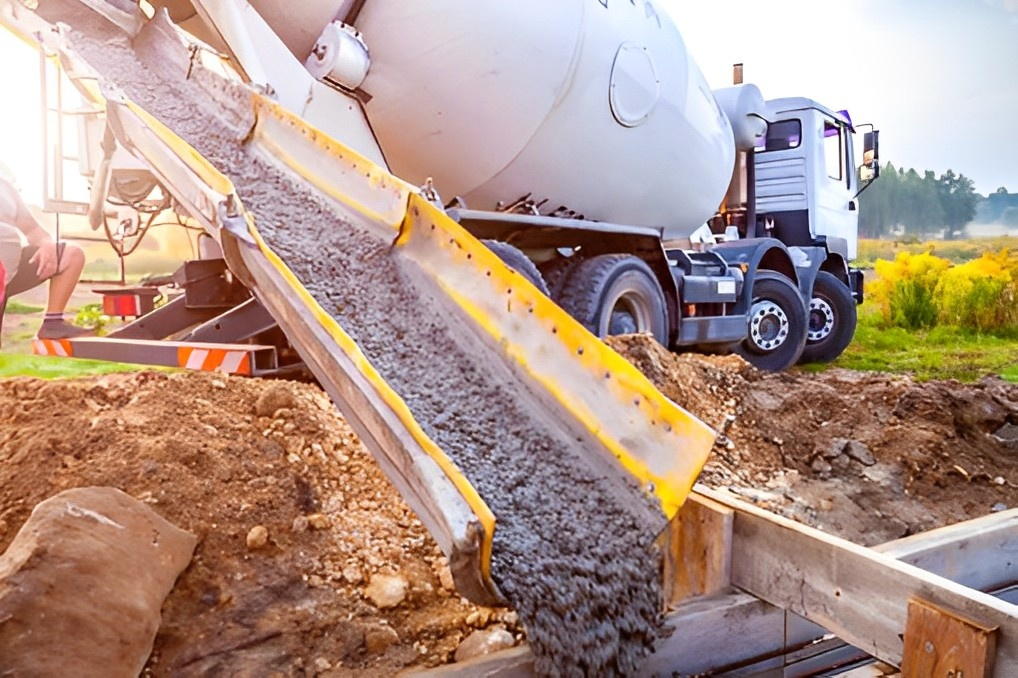

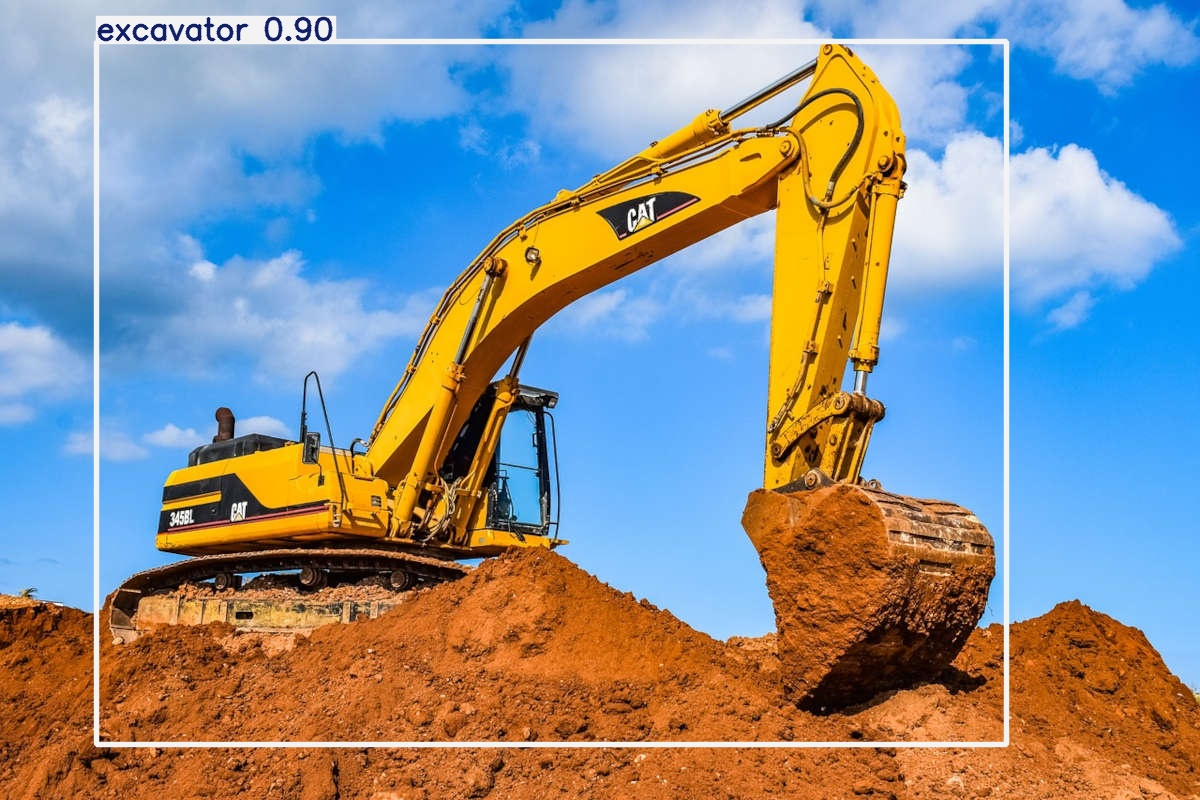

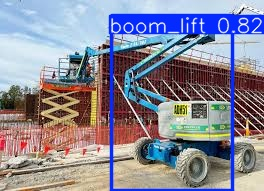

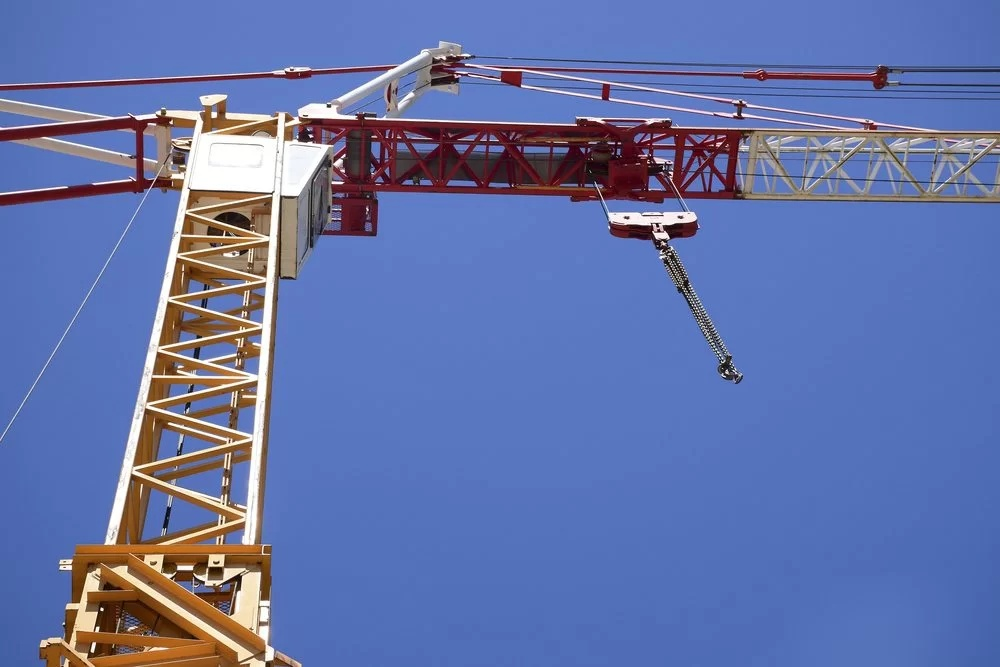

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import glob
import os

RUN_DIR = "/content/runs/detect/siteai_v3_yolov8n_512"
model = YOLO(os.path.join(RUN_DIR, "weights/best.pt"))

TEST_IMAGES_DIR = "/content/new_test_images"

# Get uploaded images
imgs = []
for ext in ("*.jpg","*.jpeg","*.png","*.webp"):
    imgs += glob.glob(os.path.join(TEST_IMAGES_DIR, ext))

print("Images found:", len(imgs))

# Run prediction
model.predict(
    source=imgs,
    imgsz=512,
    conf=0.25,
    save=True,
    project="/content/results",
    name="custom_test_preds",
    exist_ok=True
)

# Display predictions
OUT_DIR = "/content/results/custom_test_preds"

outs = []
for ext in ("*.jpg","*.jpeg","*.png","*.webp"):
    outs += glob.glob(os.path.join(OUT_DIR, ext))

print("Showing predictions:")
for p in outs[-10:]:
    display(Image(filename=p, width=900))

# 🔹 CELL 11.a — 6×6 Grid Visualization
This cell runs inference on the validation set and displays a 6×6 grid of prediction results.
It attempts to include at least one image per class detected by the model.

Using BASE_DIR: /content/dataset
Using images from: /content/dataset/valid/images
Images found: 59
Class IDs covered in grid: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


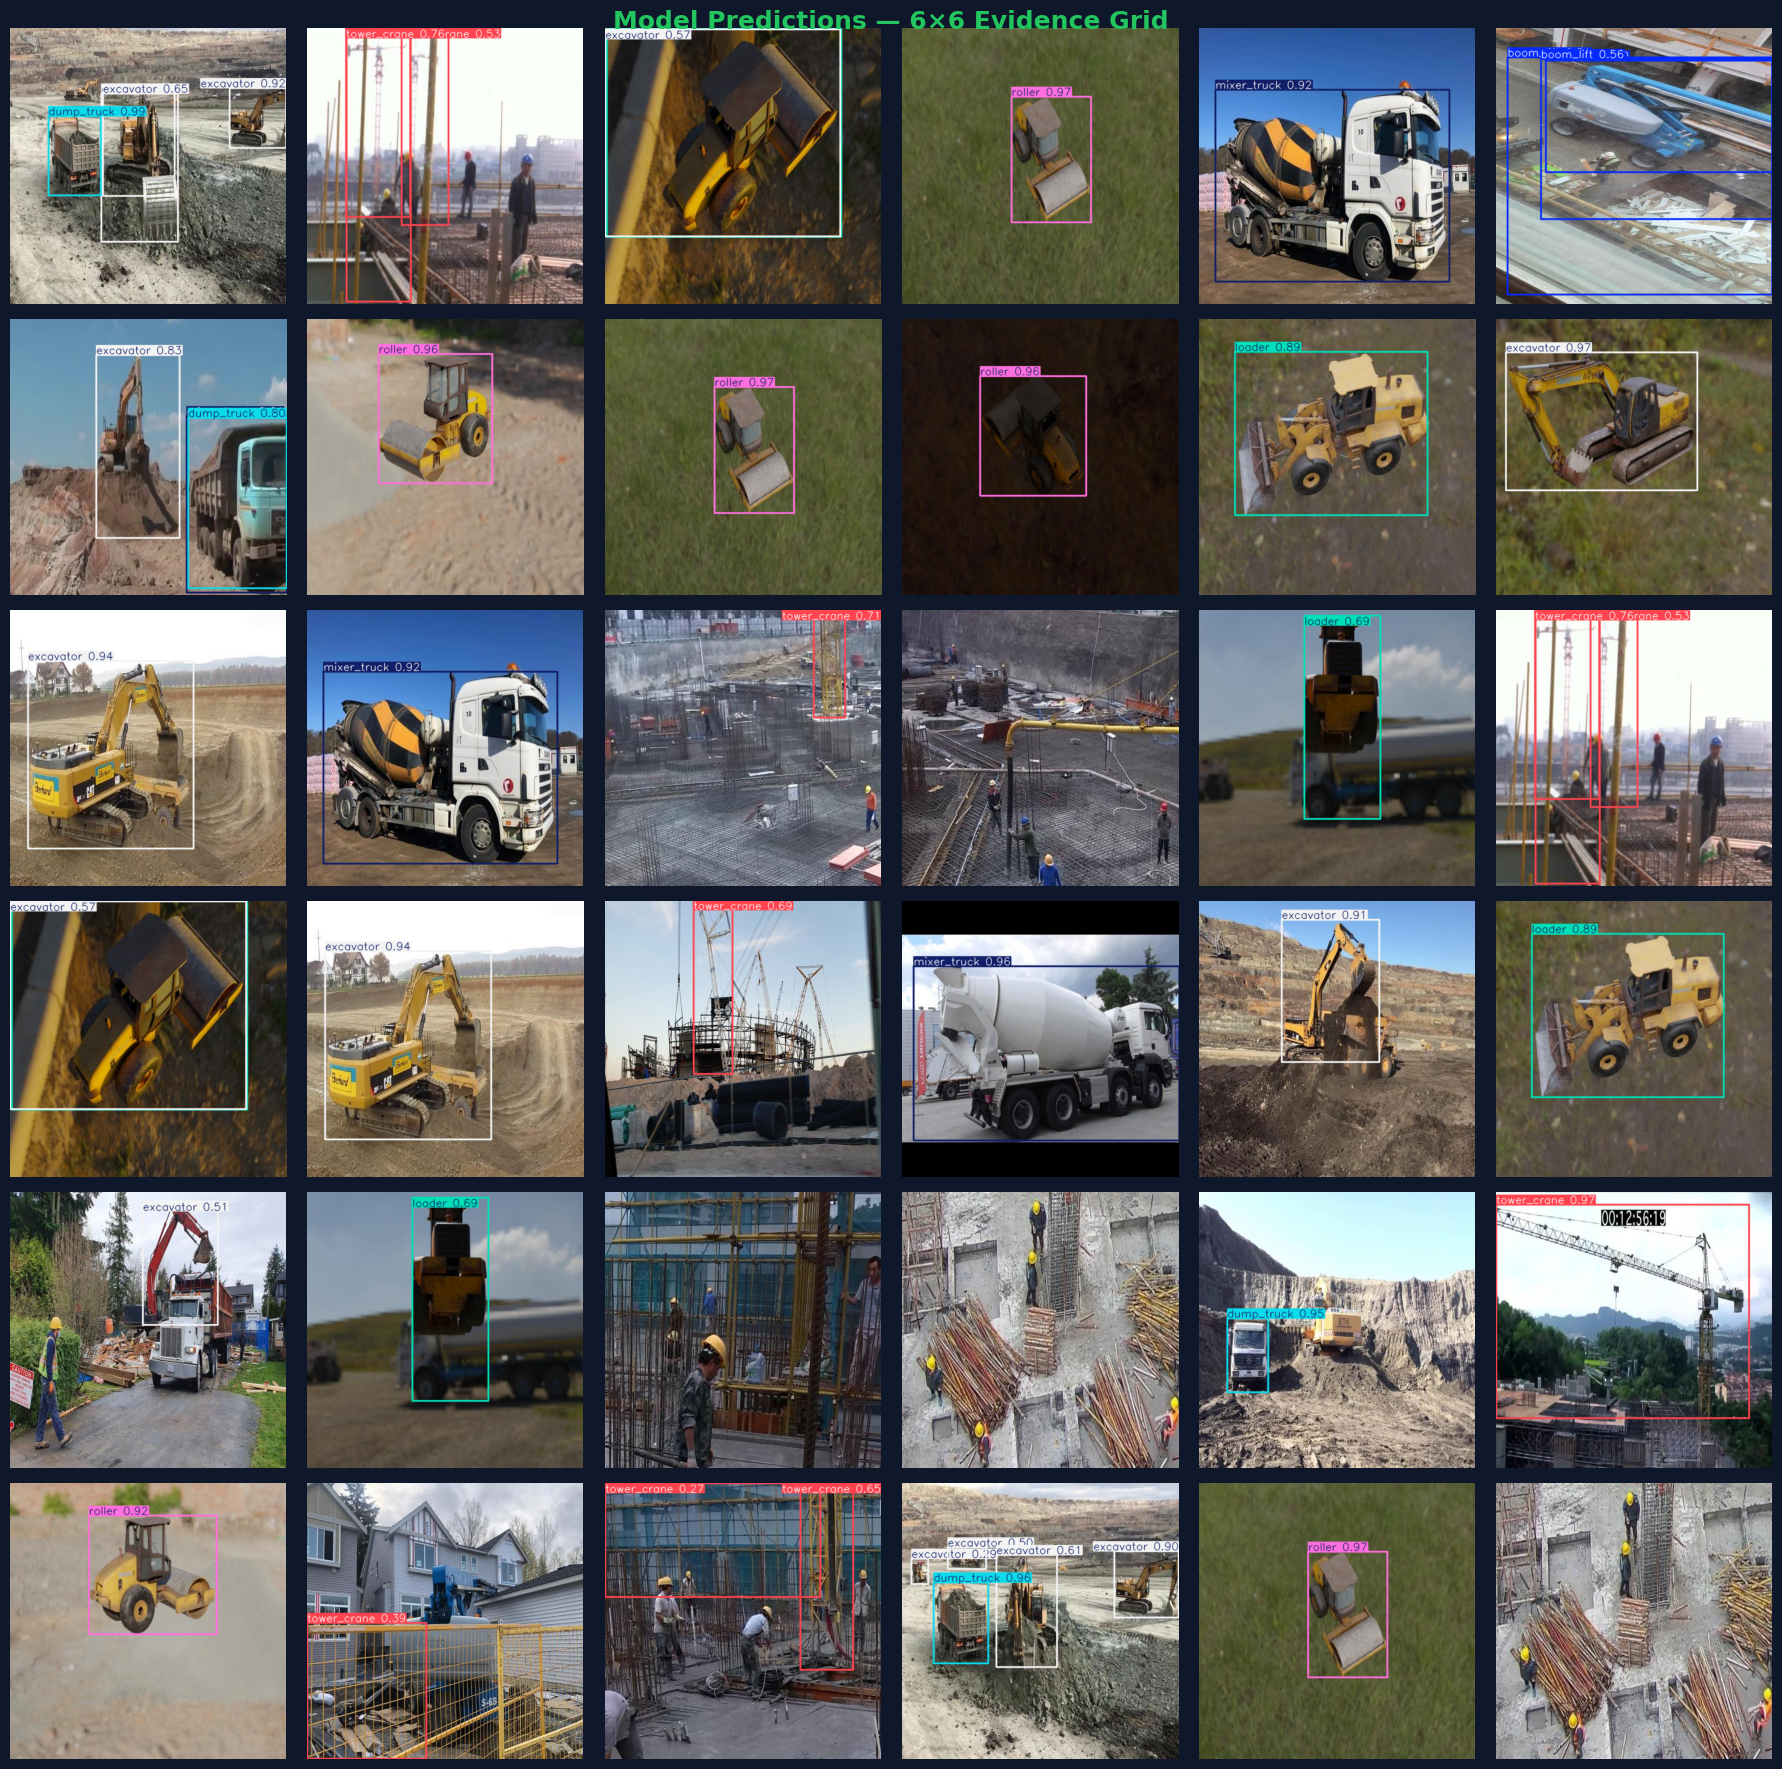

In [ ]:
from ultralytics import YOLO
import os, glob, random
import matplotlib.pyplot as plt
import cv2

RUN_DIR = "/content/runs/detect/siteai_v3_yolov8n_512"
model = YOLO(os.path.join(RUN_DIR, "weights/best.pt"))

# ---- Auto-detect dataset base ----
# Find data.yaml again and infer base folder
import glob
yaml_paths = glob.glob("/content/dataset/**/data.yaml", recursive=True)
assert len(yaml_paths) > 0, "data.yaml not found under /content/dataset/"
DATA_YAML = yaml_paths[0]
BASE_DIR = os.path.dirname(DATA_YAML)

print("Using BASE_DIR:", BASE_DIR)

# ---- Auto-detect split image folders ----
candidates = [
    os.path.join(BASE_DIR, "valid", "images"),
    os.path.join(BASE_DIR, "val", "images"),
    os.path.join(BASE_DIR, "test", "images"),
    os.path.join(BASE_DIR, "train", "images"),
]

source_dir = None
for d in candidates:
    if os.path.isdir(d):
        n = 0
        for ext in ("*.jpg","*.jpeg","*.png","*.webp"):
            n += len(glob.glob(os.path.join(d, ext)))
        if n > 0:
            source_dir = d
            break

assert source_dir is not None, f"No images found in any split folder under {BASE_DIR}"
print("Using images from:", source_dir)

# ---- Collect images ----
imgs = []
for ext in ("*.jpg","*.jpeg","*.png","*.webp"):
    imgs += glob.glob(os.path.join(source_dir, ext))

print("Images found:", len(imgs))

# Use up to 120 images to search for class coverage (faster)
sample_imgs = random.sample(imgs, k=min(120, len(imgs)))

# Run predictions (no saving needed)
preds = model.predict(sample_imgs, imgsz=512, conf=0.25, verbose=False)

# Try to pick diverse images (cover different classes)
selected = []
covered = set()

for r in preds:
    if len(selected) >= 36:
        break
    if r.boxes is not None and len(r.boxes) > 0:
        cls_ids = set(r.boxes.cls.cpu().numpy().astype(int))
        if not cls_ids.issubset(covered):
            selected.append(r)
            covered.update(cls_ids)

# Fill remaining slots randomly
while len(selected) < 36 and len(selected) < len(preds):
    selected.append(random.choice(preds))

print("Class IDs covered in grid:", sorted(list(covered)))

# ---- Display 6x6 grid ----
plt.figure(figsize=(18,18), facecolor="#0f172a")
for i, r in enumerate(selected[:36]):
    img = r.plot()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax = plt.subplot(6, 6, i+1)
    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Model Predictions — 6×6 Evidence Grid",
             fontsize=18, color="#22c55e", weight="bold")
plt.tight_layout()
plt.show()

# 🔹 CELL 12 — Reproducibility Summary

In [ ]:
import datetime
import torch
import ultralytics

print("="*50)
print("    REPRODUCIBILITY SUMMARY")
print("="*50)
print(f"  Date/Time:         {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Ultralytics ver:   {ultralytics.__version__}")
print(f"  PyTorch ver:       {torch.__version__}")
print(f"  GPU:               {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"  Model:             YOLOv8n (Nano)")
print(f"  Dataset:           SiteAI-equipment-tracker (Team7)")
print(f"  Split:             80/20 (train/val)") # Add this line back!
print(f"  Epochs:            50")
print(f"\n  --- Model Comparison ---")
print(f"  YOLOv8n:           3M params, 8.1 GFLOPs")
print(f"  YOLOv8s:           11.2M params, 28.6 GFLOPs")
print(f"  Image size:        512")
print(f"  Batch:             auto")
print(f"  Patience:          15 (early stopping)")
print("="*50)
print("\n📋 Copy this into your README reproducibility checklist.")

    REPRODUCIBILITY SUMMARY
  Date/Time:         2026-02-28 16:48:02
  Ultralytics ver:   8.4.19
  PyTorch ver:       2.10.0+cu128
  GPU:               Tesla T4
  Model:             YOLOv8n (Nano)
  Dataset:           SiteAI-equipment-tracker (Team7)
  Split:             80/20 (train/val)
  Epochs:            50

  --- Model Comparison ---
  YOLOv8n:           3M params, 8.1 GFLOPs
  YOLOv8s:           11.2M params, 28.6 GFLOPs
  Image size:        512
  Batch:             auto
  Patience:          15 (early stopping)

📋 Copy this into your README reproducibility checklist.
